In [27]:
import pandas as pd
import numpy as np
import tensorflow as tf
from sklearn.preprocessing import MinMaxScaler

In [29]:
dataset = pd.read_csv('/content/train_FD001.csv')

In [66]:

def preprocess_pipeline(df, window_size=30, rul_cap=125):
    cols_to_drop = [
        'Unnamed: 0.1', 'Unnamed: 0', 'op_setting_3', 'sensor_1',
        'sensor_5', 'sensor_10', 'sensor_16', 'sensor_18', 'sensor_19'
    ]
    df_clean = df.drop(columns=cols_to_drop, errors='ignore').copy()

    feature_cols = [c for c in df_clean.columns if c not in ['engine_id', 'cycle', 'RUL']]

    scaler = MinMaxScaler()
    df_clean[feature_cols] = scaler.fit_transform(df_clean[feature_cols])

    df_clean['RUL'] = df_clean['RUL'].clip(upper=rul_cap)

    return df_clean, feature_cols, scaler

processed_df, active_features, scaler = preprocess_pipeline(dataset)

In [31]:
def prepare_sequences(df, feature_cols, window_size=30):
    X, y = [], []
    for engine_id in df['engine_id'].unique():
        group = df[df['engine_id'] == engine_id]

        features = group[feature_cols].values
        target = group['RUL'].values

        if len(group) > window_size:
            for i in range(window_size, len(group)):
                X.append(features[i-window_size:i, :])
                y.append(target[i])

    return np.array(X), np.array(y)

X_train, y_train = prepare_sequences(processed_df, active_features)


In [32]:
X_train.shape

(17631, 30, 17)

In [61]:
def build_1d_cnn(window_size, feature_count):
    model = tf.keras.models.Sequential([
        tf.keras.layers.Input(shape=(window_size, feature_count)),

        tf.keras.layers.Conv1D(filters=64, kernel_size=3, activation='relu', padding='same'),
        tf.keras.layers.MaxPooling1D(pool_size=2),

        tf.keras.layers.Conv1D(filters=32, kernel_size=3, activation='relu', padding='same'),
        tf.keras.layers.GlobalAveragePooling1D(),

        tf.keras.layers.Dense(64, activation='relu'),
        tf.keras.layers.Dropout(0.2),
        tf.keras.layers.Dense(1)
    ])

    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model


n_features = X_train.shape[2]
model = build_1d_cnn(window_size=30, feature_count=n_features)
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_8 (Conv1D)               │ (None, 30, 64)         │         3,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_4 (MaxPooling1D)  │ (None, 15, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_9 (Conv1D)               │ (None, 15, 32)         │         6,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_4      │ (None, 32)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,681 (45.63 KB)

 Trainable params: 11,681 (45.63 KB)

 Non-trainable params: 0 (0.00 B)

In [62]:
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=64,
    validation_split=0.2, # Use 20% of engines for internal testing
    verbose=1
)

Epoch 1/50
221/221 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 4688.6309 - mae: 56.5709 - val_loss: 636.1725 - val_mae: 20.4062
Epoch 2/50
221/221 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 692.3407 - mae: 21.2452 - val_loss: 622.7773 - val_mae: 20.3082
Epoch 3/50
221/221 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 632.5591 - mae: 19.9695 - val_loss: 573.7051 - val_mae: 19.3223
Epoch 4/50
221/221 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 636.3739 - mae: 20.0024 - val_loss: 568.5039 - val_mae: 19.4026
Epoch 5/50
221/221 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 621.5527 - mae: 19.6259 - val_loss: 561.5491 - val_mae: 19.2585
Epoch 6/50
221/221 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 573.1835 - mae: 18.8116 - val_loss: 523.1730 - val_mae: 18.3719
Epoch 7/50
221/221 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 581.6274 - mae: 18.8973 - val_loss: 511.2759 - val_mae: 17.7772
Epoch 8/50
221/221 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 547.9293 - mae: 18.2165 - val_loss: 510.1699 - val_mae: 17.9972
Epoch

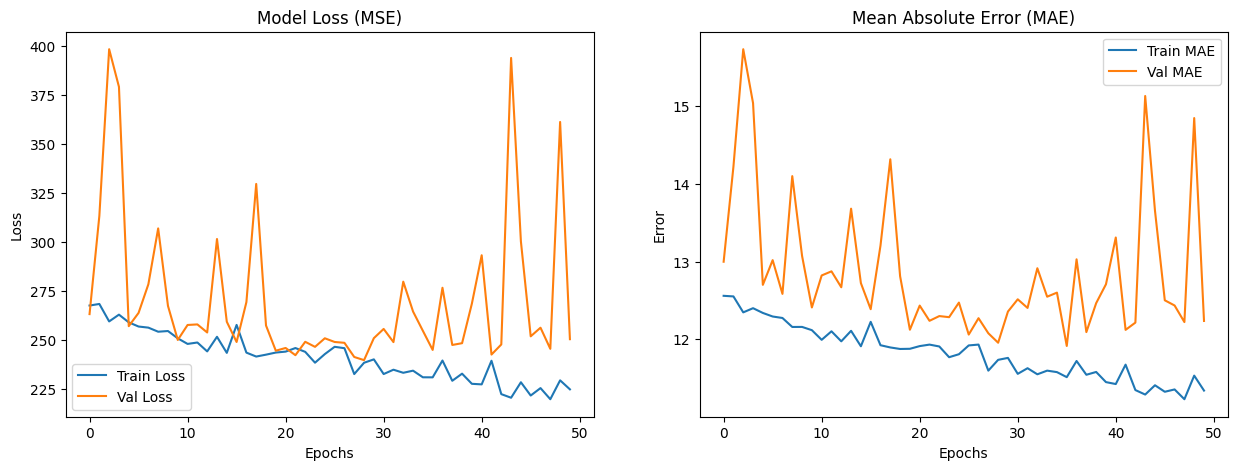

In [41]:
import matplotlib.pyplot as plt

def plot_history(history):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

    ax1.plot(history.history['loss'], label='Train Loss')
    ax1.plot(history.history['val_loss'], label='Val Loss')
    ax1.set_title('Model Loss (MSE)')
    ax1.set_xlabel('Epochs')
    ax1.set_ylabel('Loss')
    ax1.legend()

    ax2.plot(history.history['mae'], label='Train MAE')
    ax2.plot(history.history['val_mae'], label='Val MAE')
    ax2.set_title('Mean Absolute Error (MAE)')
    ax2.set_xlabel('Epochs')
    ax2.set_ylabel('Error')
    ax2.legend()

    plt.show()

plot_history(history)

In [53]:
cols_to_drop = [
        'Unnamed: 0.1', 'Unnamed: 0', 'op_setting_3', 'sensor_1',
        'sensor_5', 'sensor_10', 'sensor_16', 'sensor_18', 'sensor_19'
    ]

In [73]:
test = pd.read_csv('/content/test_FD001.csv')

In [74]:
ytest = pd.read_csv('/content/RUL_FD001.csv')

In [75]:
test.drop(cols_to_drop, axis = 1, inplace = True)


In [76]:
test

,engine_id,cycle,op_setting_1,op_setting_2,sensor_2,sensor_3,sensor_4,sensor_6,sensor_7,sensor_8,sensor_9,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_17,sensor_20,sensor_21,RUL
0,1,1,0.0023,0.0003,643.02,1585.29,1398.21,21.61,553.90,2388.04,9050.17,47.20,521.72,2388.03,8125.55,8.4052,392,38.86,23.3735,30
1,1,2,-0.0027,-0.0003,641.71,1588.45,1395.42,21.61,554.85,2388.01,9054.42,47.50,522.16,2388.06,8139.62,8.3803,393,39.02,23.3916,29
2,1,3,0.0003,0.0001,642.46,1586.94,1401.34,21.61,554.11,2388.05,9056.96,47.50,521.97,2388.03,8130.10,8.4441,393,39.08,23.4166,28
3,1,4,0.0042,0.0000,642.44,1584.12,1406.42,21.61,554.07,2388.03,9045.29,47.28,521.38,2388.05,8132.90,8.3917,391,39.00,23.3737,27
4,1,5,0.0014,0.0000,642.51,1587.19,1401.92,21.61,554.16,2388.01,9044.55,47.31,522.15,2388.03,8129.54,8.4031,390,38.99,23.4130,26
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13091,100,194,0.0049,0.0000,643.24,1599.45,1415.79,21.61,553.41,2388.02,9142.37,47.69,520.69,2388.00,8213.28,8.4715,394,38.65,23.1974,4
13092,100,195,-0.0011,-0.0001,643.22,1595.69,1422.05,21.61,553.22,2388.05,9140.68,47.60,521.05,2388.09,8210.85,8.4512,395,38.57,23.2771,3
13093,100,196,-0.0006,-0.0003,643.44,1593.15,1406.82,21.61,553.04,2388.11,9146.81,47.57,521.18,2388.04,8217.24,8.4569,395,38.62,23.2051,2
13094,100,197,-0.0038,0.0001,643.26,1594.99,1419.36,21.61,553.37,2388.07,9148.85,47.61,521.33,2388.08,8220.48,8.4711,395,38.66,23.2699,1


In [78]:
test.drop('RUL', axis = 1, inplace = True)

In [79]:
feature_cols = [c for c in test.columns if c not in ['engine_id', 'cycle', 'RUL']]
test[feature_cols] = scaler.transform(test[feature_cols])

In [80]:

def get_last_windows(df, feature_cols, window_size=30):
    last_windows = []
    engine_ids = []

    for engine_id in df['engine_id'].unique():
        group = df[df['engine_id'] == engine_id]
        if len(group) >= window_size:
            last_window = group[feature_cols].values[-window_size:, :]
            last_windows.append(last_window)
            engine_ids.append(engine_id)

    return np.array(last_windows), engine_ids

X_test, test_engine_ids = get_last_windows(test, active_features)

In [81]:
from sklearn.metrics import mean_absolute_error, mean_squared_error


y_pred = model.predict(X_test)
y_pred = np.clip(y_pred, 0, 125)

actual_rul_values = np.array(ytest).flatten()
actual_rul_values = np.clip(actual_rul_values, 0, 125)

mae = mean_absolute_error(actual_rul_values, y_pred)
rmse = np.sqrt(mean_squared_error(actual_rul_values, y_pred))

print(f"Final Test MAE: {mae:.2f}")
print(f"Final Test RMSE: {rmse:.2f}")

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 
Final Test MAE: 50.55
Final Test RMSE: 64.51


In [63]:
ytest

,0
0,112
1,98
2,69
3,82
4,91
...,...
95,137
96,82
97,59
98,117
